# 05 · How far from shore? Siting and layout together — *work in progress*

Moving a farm further offshore gives stronger, steadier wind but a longer export cable back to land.
This notebook adds distance to shore as a design variable alongside the turbine positions and
optimises three objectives at once:

1. maximise AEP
2. minimise inter-array cable (MST, as in notebooks 03–04)
3. minimise export cable (landfall to a substation at the farm centroid)

The export cable is kept as a separate objective rather than added to the array cable, because the
two are different products with different copper content per km.

> **Status.** How wind speed changes with distance from the coast is currently a placeholder
> (see the assumptions cell below), and the copper-per-km figures are not filled in yet.
> The optimisation machinery works; the numbers it produces should not be read as results until
> both are replaced with sourced data.

In [1]:
%pip install -q py_wake==2.6.20 topfarm==2.6.2 pymoo==0.6.2

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.2/347.2 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [13]:
%pip install -q rasterio pyproj global-land-mask

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.4 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree

from py_wake.site import XRSite
from py_wake.site.xrsite import GlobalWindAtlasSite
from py_wake.examples.data.dtu10mw import DTU10MW
from py_wake.literature.gaussian_models import Niayifar_PorteAgel_2016
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

FIG = Path("figures"); FIG.mkdir(exist_ok=True)

In [9]:
DATA = Path("data/dogger_bank_gwa.nc")

def load_dogger_bank_site():
    """Dogger Bank wind climate from the Global Wind Atlas (54.75 N, 1.90 E, 119 m, open sea).
    Downloaded once and cached in data/ so later runs don't depend on the GWA API."""
    if DATA.exists():
        return XRSite(xr.load_dataset(DATA))
    print("Downloading Dogger Bank wind climate from the Global Wind Atlas...")
    site = GlobalWindAtlasSite(lat=54.75, long=1.90, height=119, roughness=0.0002)
    DATA.parent.mkdir(exist_ok=True)
    site.ds.to_netcdf(DATA)
    return site

## Assumptions

- The Global Wind Atlas point used in notebook 04 is taken to lie about **150 km** from the coast,
  and its wind climate is used as the reference (relative wind speed = 1.0 there).
- The wind speed data is taken from Global wind atlas gis files for UK for 100m and 150m height. From this the value for a hubheight of 119m was calculated.
- The wind rose shape (direction frequencies) is assumed not to change with distance.

Nearest coast: 54.120 N, -0.085 E | Dogger Bank is 146.65 km offshore
             U119_ms  U_rel
distance_km                
1.0            9.248  0.910
10.0           9.692  0.954
30.0           9.973  0.982
50.0          10.126  0.997
100.0         10.238  1.008
150.0         10.162  1.000


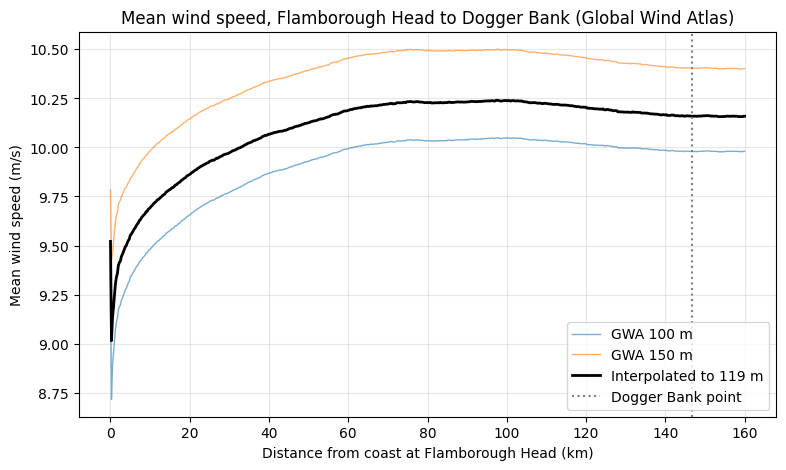

In [14]:
import urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from pyproj import Geod
from global_land_mask import globe

DOGGER_BANK = (1.90, 54.75)      # lon, lat (same point as notebooks 04-05)
HUB_HEIGHT = 119.0               # DTU 10 MW
Path("data").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

# 1. Download the Global Wind Atlas UK layers at 100 m and 150 m
for h in (100, 150):
    tif = Path(f"GBR_wind-speed_{h}m.tif")
    if not tif.exists():
        print(f"Downloading {h} m layer...")
        urllib.request.urlretrieve(f"https://globalwindatlas.info/api/gis/country/GBR/wind-speed/{h}", tif)

# 2. Find the nearest coast to Dogger Bank
geod = Geod(ellps="WGS84")
LON, LAT = np.meshgrid(np.arange(-3.0, 1.5, 0.005), np.arange(52.5, 56.5, 0.005))
land = globe.is_land(LAT, LON)
_, _, d = geod.inv(np.full(land.sum(), DOGGER_BANK[0]), np.full(land.sum(), DOGGER_BANK[1]),
                   LON[land], LAT[land])
coast = (LON[land][d.argmin()], LAT[land][d.argmin()])
azimuth, _, d_ref = geod.inv(*coast, *DOGGER_BANK)
D_REF_KM = d_ref / 1000
print(f"Nearest coast: {coast[1]:.3f} N, {coast[0]:.3f} E | Dogger Bank is {D_REF_KM:.2f} km offshore")

# 3. Sample both layers every 250 m along the line from the coast out to 160 km
d_km = np.arange(0, 160.001, 0.25)
lon, lat, _ = geod.fwd(np.full(d_km.size, coast[0]), np.full(d_km.size, coast[1]),
                       np.full(d_km.size, azimuth), d_km * 1000)
U = {}
for h in (100, 150):
    with rasterio.open(f"GBR_wind-speed_{h}m.tif") as src:
        U[h] = np.array([v[0] for v in src.sample(zip(lon, lat))], dtype=float)

# 4. Interpolate to hub height (log-height) and normalise to the Dogger Bank point
alpha = np.log(HUB_HEIGHT / 100) / np.log(150 / 100)
U_hub = U[100] * (U[150] / U[100]) ** alpha

df = pd.DataFrame({"distance_km": d_km, "lon": lon, "lat": lat,
                   "U100_ms": U[100], "U150_ms": U[150], "U119_ms": U_hub})
df["U_rel"] = df.U119_ms / np.interp(D_REF_KM, df.distance_km, df.U119_ms)
df.round(4).to_csv("data/dogger_bank_transect.csv", index=False)

print(df.set_index("distance_km").loc[[1, 10, 30, 50, 100, 150], ["U119_ms", "U_rel"]].round(3))

# 5. Plot
plt.figure(figsize=(9, 5))
plt.plot(df.distance_km, df.U100_ms, lw=1, alpha=0.6, label="GWA 100 m")
plt.plot(df.distance_km, df.U150_ms, lw=1, alpha=0.6, label="GWA 150 m")
plt.plot(df.distance_km, df.U119_ms, lw=2, color="k", label="Interpolated to 119 m")
plt.axvline(D_REF_KM, color="gray", ls=":", label="Dogger Bank point")
plt.xlabel("Distance from coast at Flamborough Head (km)")
plt.ylabel("Mean wind speed (m/s)")
plt.title("Mean wind speed, Flamborough Head to Dogger Bank (Global Wind Atlas)")
plt.grid(alpha=0.3); plt.legend(loc="lower right")
plt.savefig("figures/05_wind_speed_transect.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
wt = DTU10MW()
TI = 0.06
n_wt = 8
MIN_SPACING = 4 * wt.diameter()     # 713 m
LEASE_X, LEASE_Y = 3000, 2000
D_REF_KM = 146.65                   # GWA Dogger Bank point, measured from the coast at Flamborough Head
D_MIN_KM, D_MAX_KM = 10, 150
POP_SIZE, N_GEN, SEED = 80, 100, 1

# Wind speed vs distance offshore, from Global Wind Atlas 100 m and 150 m layers
# interpolated to 119 m hub height (built by wind_speed_transect.ipynb)
TRANSECT = Path("data/dogger_bank_transect.csv")
if not TRANSECT.exists():           # e.g. notebook opened in Colab straight from GitHub
    TRANSECT.parent.mkdir(exist_ok=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/YOUR-USERNAME/offshore-wind-layout-cable-tradeoff/main/data/dogger_bank_transect.csv",
        TRANSECT)

transect = pd.read_csv(TRANSECT)
d_grid_km = transect.distance_km.values
U_rel = transect.U_rel.values       # 1.0 at the Dogger Bank point

# Dogger Bank wind climate, with a speed-up factor that varies along x (= distance offshore)
ds = load_dogger_bank_site().ds.copy().drop_vars("h", errors="ignore")
y_grid = np.array([-5e3, 10e3])
ds = ds.assign_coords(x=d_grid_km * 1e3, y=y_grid)
ds["Speedup"] = (("x", "y"), np.repeat(U_rel[:, None], len(y_grid), axis=1))
macro_site = XRSite(ds, interp_method="linear")
wf_macro = Niayifar_PorteAgel_2016(macro_site, wt)

## Sanity check before optimising

In [17]:
x0 = np.linspace(0, 2400, 4).repeat(2)
y0 = np.tile(np.linspace(0, 1600, 2), 4)
aep_ref = wf_macro(x0 + D_REF_KM * 1e3, y0, TI=TI).aep().sum().values
aep_near = wf_macro(x0 + D_MIN_KM * 1e3, y0, TI=TI).aep().sum().values
u_ratio = np.interp(D_MIN_KM, d_grid_km, U_rel)

print(f"AEP at {D_REF_KM} km: {aep_ref:.1f} GWh | at {D_MIN_KM} km: {aep_near:.1f} GWh")
print(f"Wind speed ratio {D_MIN_KM} km / {D_REF_KM} km: {u_ratio:.3f}")
print(f"AEP ratio: {aep_near / aep_ref:.3f}  (cube of wind ratio would give {u_ratio ** 3:.3f}; "
      "AEP falls less than that because turbines cap out at rated power)")

AEP at 146.65 km: 380.1 GWh | at 10 km: 359.9 GWh
Wind speed ratio 10 km / 146.65 km: 0.954
AEP ratio: 0.947  (cube of wind ratio would give 0.869; AEP falls less than that because turbines cap out at rated power)


In [18]:
def array_cable_km(x, y):
    return minimum_spanning_tree(squareform(pdist(np.column_stack([x, y])))).sum() / 1000


class SitingAndLayout(ElementwiseProblem):
    def __init__(self):
        xl = [0] * (2 * n_wt) + [D_MIN_KM]
        xu = [LEASE_X] * n_wt + [LEASE_Y] * n_wt + [D_MAX_KM]
        super().__init__(n_var=len(xl), n_obj=3, n_ieq_constr=1, xl=xl, xu=xu)

    def _evaluate(self, v, out, *args, **kwargs):
        x, y, d_shore = v[:n_wt], v[n_wt:2 * n_wt], v[-1]
        x_abs = x + d_shore * 1e3                 # lease box starts d_shore km offshore
        aep = wf_macro(x_abs, y, TI=TI).aep().sum().values
        export_km = d_shore + x.mean() / 1000     # landfall -> substation at centroid
        out["F"] = [-aep, array_cable_km(x, y), export_km]
        out["G"] = [MIN_SPACING - pdist(np.column_stack([x, y])).min()]


def initial_population(problem, seed_row):
    # Random layouts, with the starting grid as the first member so the search
    # always has one feasible, sensible layout to build from.
    rng = np.random.default_rng(SEED)
    X0 = rng.uniform(problem.xl, problem.xu, size=(POP_SIZE, problem.n_var))
    X0[0] = seed_row
    return X0


problem = SitingAndLayout()
X0 = initial_population(problem, np.concatenate([x0, y0, [D_REF_KM]]))
result = minimize(problem, NSGA2(pop_size=POP_SIZE, sampling=X0), ("n_gen", N_GEN), seed=SEED, verbose=False)

front = pd.DataFrame({
    "Distance_to_shore_km": result.X[:, -1],
    "AEP_GWh": -result.F[:, 0],
    "Array_cable_km": result.F[:, 1],
    "Export_cable_km": result.F[:, 2],
}).sort_values("Distance_to_shore_km").reset_index(drop=True)
print(front.round(2).to_string())

    Distance_to_shore_km  AEP_GWh  Array_cable_km  Export_cable_km
0                  10.02   360.03            6.98            11.29
1                  10.03   355.28            5.42            11.46
2                  10.03   354.75            5.23            11.50
3                  10.05   358.51            6.17            11.49
4                  10.28   356.75            5.71            11.64
5                  11.26   359.88            6.32            12.61
6                  11.26   360.20            6.39            12.68
7                  11.26   358.84            5.91            12.72
8                  11.52   355.80            5.27            13.00
9                  11.52   355.98            5.21            13.00
10                 11.75   357.43            5.65            13.27
11                 11.75   361.61            7.26            13.18
12                 12.65   361.93            7.07            14.13
13                 13.74   362.67            6.75            1

## Copper (to be filled in)

Copper is calculated after the optimisation rather than inside it, so the Pareto front does not
depend on the copper intensity values. Set the two constants below (tonnes of copper per km for
array and export cable, from a cited source) to add a copper column.

In [21]:
CU_ARRAY_T_PER_KM = 8.68    # 33kV - 400 mm2
CU_EXPORT_T_PER_KM = 26.8   # 220 kV HVAC Export Cable (3-Core)

if CU_ARRAY_T_PER_KM is not None and CU_EXPORT_T_PER_KM is not None:
    front["Copper_t"] = (front.Array_cable_km * CU_ARRAY_T_PER_KM
                         + front.Export_cable_km * CU_EXPORT_T_PER_KM)
    print(front.round(1).to_string())
else:
    print("Copper intensities not set yet - skipping copper column.")

    Distance_to_shore_km  AEP_GWh  Array_cable_km  Export_cable_km  Copper_t
0                   10.0    360.0             7.0             11.3     363.1
1                   10.0    355.3             5.4             11.5     354.0
2                   10.0    354.7             5.2             11.5     353.6
3                   10.1    358.5             6.2             11.5     361.6
4                   10.3    356.7             5.7             11.6     361.4
5                   11.3    359.9             6.3             12.6     392.8
6                   11.3    360.2             6.4             12.7     395.2
7                   11.3    358.8             5.9             12.7     392.3
8                   11.5    355.8             5.3             13.0     394.2
9                   11.5    356.0             5.2             13.0     393.6
10                  11.7    357.4             5.6             13.3     404.7
11                  11.7    361.6             7.3             13.2     416.3

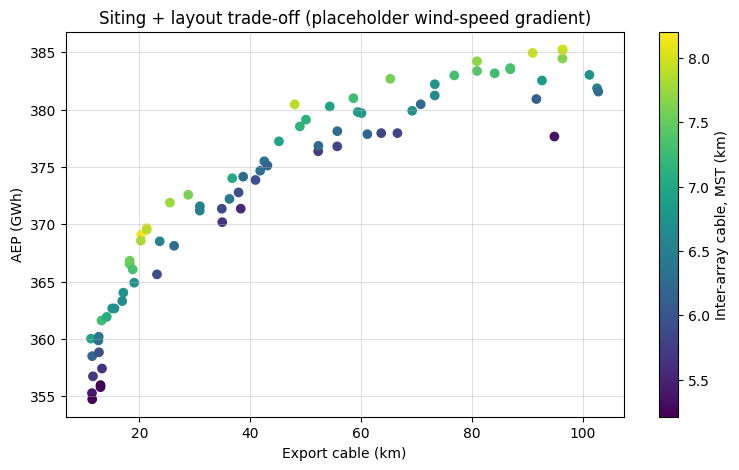

In [22]:
plt.figure(figsize=(9, 5))
sc = plt.scatter(front.Export_cable_km, front.AEP_GWh, c=front.Array_cable_km, cmap="viridis")
plt.colorbar(sc, label="Inter-array cable, MST (km)")
plt.xlabel("Export cable (km)"); plt.ylabel("AEP (GWh)")
plt.title("Siting + layout trade-off (placeholder wind-speed gradient)")
plt.grid(True, alpha=0.4)
plt.savefig(FIG / "05_siting_front.png", dpi=150, bbox_inches="tight")
plt.show()